# Mandat no 1 - Statistiques descriptives et inférence statistique

Mise en place pour le mandat.

In [1]:
# Probabilités
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import math
from IPython.display import display, Math, Markdown

In [2]:
class statistik:
    
    def __init__(self):
        pass

    # On compte le nombre de façons d'arranger les éléments
    def permutation(self, n, r: int | list | None, type: str | None):
        match type:
            case None:
                return math.factorial(n)
            case "subset":
                if r is None:
                    raise TypeError
                return math.factorial(n) / math.factorial(n-r)
            case "sim-object":
                if r is None:
                    raise TypeError
                denum = 1
                for v in r:
                    denum *= math.factorial(v)
                return math.factorial(n) / denum
            
    # On compte le nombre de façons d'arranger les éléments sans tenir compte de l'ordre
    def combinaison(self, n, r):
        return math.factorial(n) / (math.factorial(r) * math.factorial(n-r))
    

In [3]:
class distribution:
    
    def __init__(self, stat: statistik):
        self.stat = stat

    def P(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def P_cumul(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def E(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def E_cuml(self):
        raise NotImplementedError("Subclasses must implement this method")

    def V(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def V_cumul(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def cumul(self):
        raise NotImplementedError("Subclasses must implement this method")

In [4]:
class binomial_distribution(distribution):

    def P(self, n, x, p):
        return self.stat.combinaison(n, x) * p**x * (1-p)**(n-x)
    
    def P_cumul(self, n, x, p):
        Ps = np.array(x, dtype=float)
        for i, v in enumerate(x):
            Ps[i] = self.P(n, v, p)
        return np.sum(Ps)
    
    def E(self, n, p):
        return n * p
    
    def E_cuml(self, n, x, p):
        Ps = np.array(x, dtype=float)
        Es = np.array(x, dtype=float)
        for i, v in enumerate(x):
            P = self.P(n, v, p)
            Ps[i] = P
            Es[i] = v * P
        return np.sum(Es)

    def V(self, n, p):
        return n * p * (1-p)
    
    def V_cumul(self, n, x, p):
        Ps = np.array(x, dtype=float)
        Es = np.array(x, dtype=float)
        Vs = np.array(x, dtype=float)
        for i, v in enumerate(x):
            P = self.P(n, v, p)
            Ps[i] = P
            Es[i] = v * P
            Vs[i] = (v - Es[i])**2 * P
        return np.sum(Vs)
    
    def cumul(self, n, x, p):
        Ps = np.array(x, dtype=float)
        Es = np.array(x, dtype=float)
        Vs = np.array(x, dtype=float)
        for i, v in enumerate(x):
            P = self.P(n, v, p)
            Ps[i] = P
            Es[i] = v * P
            Vs[i] = (v - Es[i])**2 * P
        return np.sum(Ps), np.sum(Es), np.sum(Vs)

In [5]:
class machine_a_sous:
    def __init__(self, roues, pictos):
        self.roues = roues
        self.pictos = pictos

    def probabilite_win(self):
        # Calcul de la probabilité de gagner
        return 1 * (1 / self.pictos)**(self.roues - 1) # Probabilité d'obtenir un pictogramme spécifique sur une roue
    
    

In [6]:
stat = statistik()
# 3 roues, 8 pictogrammes
machine1 = machine_a_sous(3, 8)
# 4 roues, 5 pictogrammes
machine2 = machine_a_sous(4, 5)

## i) Configuration des roues

Comparaison des probabilité où tout les pictogrammes sont identiques: $P=\left(\frac{1}{s}\right)^{r-1}$, où $r$ est le nombre de roues et $s$ le nombre de pictogrammes par roue.

In [7]:
# i
print(f"Probabilité de gagner un pouvoir à la machine 1 (3 roues, 8 pictogrammes): {machine1.probabilite_win()*100:.2f}%")
print(f"Probabilité de gagner un pouvoir à la machine 2 (4 roues, 5 pictogrammes): {machine2.probabilite_win()*100:.2f}%")

Probabilité de gagner un pouvoir à la machine 1 (3 roues, 8 pictogrammes): 1.56%
Probabilité de gagner un pouvoir à la machine 2 (4 roues, 5 pictogrammes): 0.80%


## ii) Permutation des combinaisons

Comparaison des combinaisons des différentes configurations de roues.

On utilise les permutations, $P(m,r)=\frac{m!}{(m-r)!}$

In [8]:
#ii
# On va utiliser la permutation pour avoir toutes les façons d'arranger les éléments
print(f"Permutation de machine 1 : {stat.permutation(machine1.pictos, machine1.roues, "subset"):.0f}")
print(f"Permutation de machine 2 : {stat.permutation(machine2.pictos, machine2.roues, "subset"):.0f}")

Permutation de machine 1 : 336
Permutation de machine 2 : 120


## iii) Distribution binomiale

On cherche $P(X\ge2)=1-[P(X=0)+P(X=1)]$, avec $P(X=x)=\binom{5}{x}p^x(1-p)^{5-x}$.

Où $x$ est le nombre d'essai réussi.

Avoir le même pictogramme sur l'ensemble des roues au moins 2 fois sur un total de 5 essais :
Machine 1 : 
	 Probabilité cumulative : 0.2366%
	 Moyenne : 0.0048
	 Variance : 0.0096
Machine 2 : 
	 Probabilité cumulative : 0.0630%
	 Moyenne : 0.0013
	 Variance : 0.0025


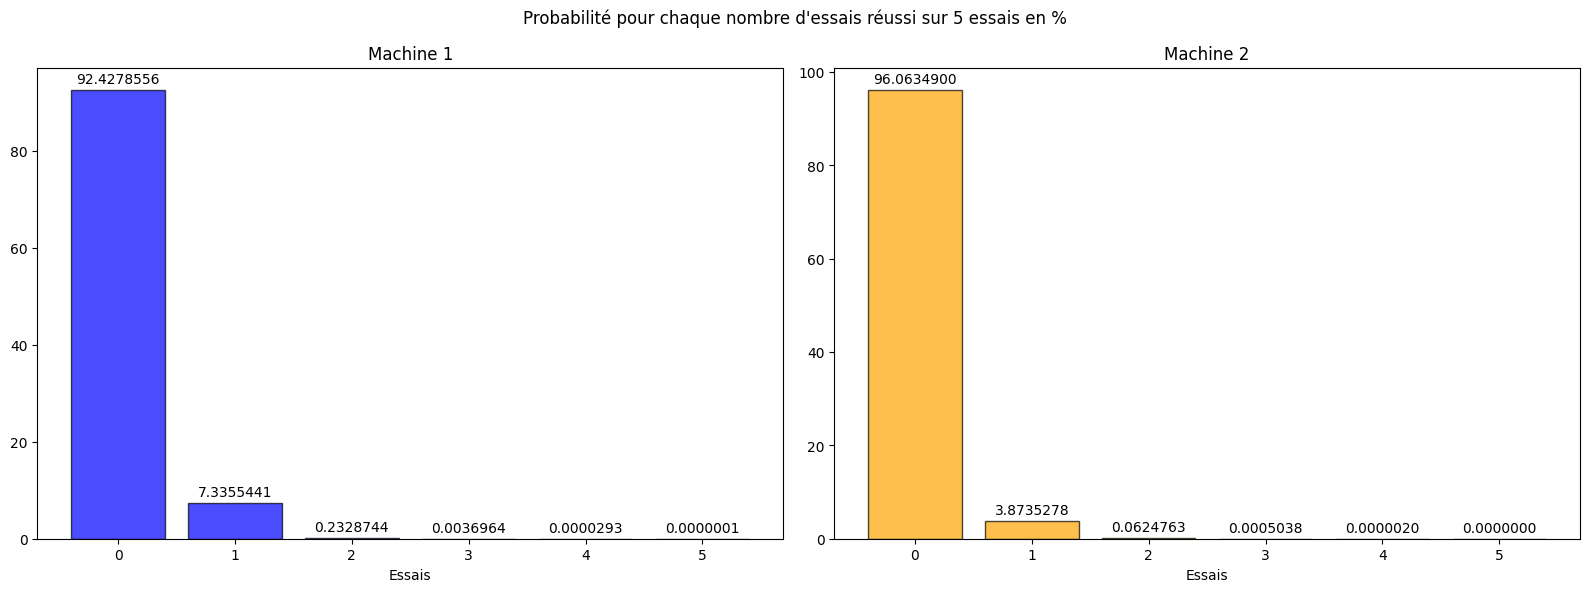

In [9]:
# iii
print("Avoir le même pictogramme sur l'ensemble des roues au moins 2 fois sur un total de 5 essais :")
plt.figure(figsize=(16, 6))
n = 5 # Essais
x = np.arange(6)
bd = binomial_distribution(stat)

p = machine1.probabilite_win() # Probabilité d'avoir le même pictogramme sur toutes les roues
P, E, V = bd.cumul(n, x[2::], p)
print("Machine 1 : ")
print(f"\t Probabilité cumulative : {P*100:.4f}%")
print(f"\t Moyenne : {E:.4f}")
print(f"\t Variance : {V:.4f}")

Ps = np.array([
    bd.P(n, 0, p),
    bd.P(n, 1, p),
    bd.P(n, 2, p),
    bd.P(n, 3, p),
    bd.P(n, 4, p),
    bd.P(n, 5, p),
]) * 100

plt.subplot(1, 2, 1)
plt.bar(x, Ps, alpha=0.7, color='blue', edgecolor='black')
for i in range(len(Ps)):
    plt.annotate(f"{Ps[i]:.7f}", xy=(x[i], Ps[i]), xytext=(0, 5),
                 textcoords="offset points", ha='center')
plt.title(f"Machine 1")
plt.xlabel("Essais")

p = machine2.probabilite_win() # Probabilité d'avoir le même pictogramme sur toutes les roues
P, E, V = bd.cumul(n, x[2::], p)
print("Machine 2 : ")
print(f"\t Probabilité cumulative : {P*100:.4f}%")
print(f"\t Moyenne : {E:.4f}")
print(f"\t Variance : {V:.4f}")

Ps = np.array([
    bd.P(n, 0, p),
    bd.P(n, 1, p),
    bd.P(n, 2, p),
    bd.P(n, 3, p),
    bd.P(n, 4, p),
    bd.P(n, 5, p),
]) * 100

plt.subplot(1, 2, 2)
plt.bar(x, Ps, alpha=0.7, color='orange', edgecolor='black')
for i in range(len(Ps)):
    plt.annotate(f"{Ps[i]:.7f}", xy=(x[i], Ps[i]), xytext=(0, 5),
                 textcoords="offset points", ha='center')
plt.title(f"Machine 2")
plt.xlabel("Essais")


plt.suptitle('Probabilité pour chaque nombre d\'essais réussi sur 5 essais en %')
plt.tight_layout()
plt.show()




# Mandat no 1.2 - Jeu de fléchette

Les axes $(X,Y)$ sont indépendants lors d'un lancer de fléchette donc la corrélation $\rho_{XY}=0$, ce qui implique que la covariance $Cov(X,Y)=0$.

Avec une position $(X,Y)$, on utilise la fonction de densité normal bivarié pour calculer la probabilité $P(X,Y)$ d'une variable aléatoire à deux dimensions à l'aide d'une double intégral. La position a une moyenne située au centre $(\mu_x, \mu_y) = (0,0)$ de la cible avec un équart-type $\sigma_x=0.1$ et $\sigma_y\in\{0.05,0.4\}$ selon $z$. On s'intéresse à la probabilité de réussir a envoyer les fléchettes dans le cercle du millieu de la cible de rayon de $0.1$ m.

Puisque $P(X,Y)$ n'est pas assez précis, on utilise une approximation de Monte-Carlo avec 1 millions de points.

In [10]:
# Jeu de fléchette

def f_xy(x, y, o_x, o_y, u_x, u_y, p):
    const = (1/(2*sp.pi*o_x*o_y*sp.sqrt(1-p**2)))
    a = 1 / (2*(1-p**2))
    b = (x-u_x)**2 / o_x**2
    c = 2*p * ((x-u_x)*(y-u_y)) / (o_x*o_y)
    d = (y-u_y)**2 / o_y**2
    exp = sp.exp(-a * (b - c + d))
    return const*exp

def probability_z(z):

    x, y, o_x, o_y, u_x, u_y, p = sp.symbols('x y o_x o_y u_x u_y p')

    r = 0.1

    u_x = 0
    u_y = 0
    o_x = 0.1

    if z > 10:
        o_y = 0.4
    elif z < 1:
        o_y = 0.05

    p = 0 # aucune corrélation entre x et y
    cov = 0 # puisque p = 0

    fxyz = f_xy(x, y, o_x, o_y, u_x, u_y, p)
    fxz = fxyz.subs({y:0})
    fyz = fxyz.subs({x:0})
    P = sp.integrate(fxyz, (x, -r, r), (y, -sp.sqrt(r**2 - -r**2), sp.sqrt(r**2 - r**2)))


    print(f"Aucune corrélation entre x et y donc p = {p}")
    print(f"Si p = {0} alors la covariance cov = {cov}")

    print()
    print(f'Pour z = {z} : ')

    display(Math(f' f(x,y|z) = {sp.latex(fxyz)}'))
    display(Math(f' f(x|z) = {sp.latex(fxz)}'))
    display(Math(f' f(y|z) = {sp.latex(fyz)}'))
    display(Markdown(f" Probabilité à l\'aide de $f(x,y|z)$ = {P*100:.4f}%"))

    N = 1_000_000
    A = np.pi * r**2

    x = np.random.normal(u_x, o_x, N)
    y = np.random.normal(u_y, o_y, N)

    inside = (x**2 + y**2) <= r**2
    N1 = np.sum(inside)

    P = N1/N
    display(Markdown(f' Probabilité à l\'aide de Monte-Carlo = {P*100:.4f}%'))

probability_z(0.5)
print('------------------------------------------------------------------------')
probability_z(20)






Aucune corrélation entre x et y donc p = 0
Si p = 0 alors la covariance cov = 0

Pour z = 0.5 : 


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

 Probabilité à l'aide de $f(x,y|z)$ = 33.9748%

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

 Probabilité à l'aide de $f(x,y|z)$ = 9.4323%

 Probabilité à l'aide de Monte-Carlo = 11.0513%

# Mandat no 2 - Statistiques descriptives et inférence statistique

## i) Extraction des statistiques descriptives

Objectif : calculer les statistiques descriptives des temps de jeu (en minutes) à partir de `TempsDeJeu.txt` et afficher les résultats dans l’ordre demandé :
- moyenne échantillonnale,
- médiane,
- mode,
- écart-type,
- minimum,
- maximum,
- étendue.

Le code lit les 100 observations et extrait les variables utilisées dans les sections suivantes.

In [11]:
# Statistiques descriptives et inférence statistique
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

temps_de_jeu = []
with open("TempsDeJeu.txt", "r", encoding="utf-8") as f:
    temps_de_jeu = np.array(
        [int(float(ligne.strip())) for ligne in f]
    )
    
moyenne = np.mean(temps_de_jeu)
mediane = np.median(temps_de_jeu)
ecart_type = np.std(temps_de_jeu)
mode = np.bincount(temps_de_jeu).argmax()
minimum = np.min(temps_de_jeu)
maximum = np.max(temps_de_jeu)
etendue = maximum - minimum

print(f"Moyenne\t\t: {moyenne}")
print(f"Médiane\t\t: {mediane}")
print(f"Écart-type\t: {ecart_type:.2f}")
print(f"Mode\t\t: {mode}")
print(f"Minimum\t\t: {minimum}")
print(f"Maximum\t\t: {maximum}")
print(f"Étendue\t\t: {etendue}")

Moyenne		: 280.58
Médiane		: 279.0
Écart-type	: 50.12
Mode		: 253
Minimum		: 148
Maximum		: 382
Étendue		: 234


## ii) Construction de l’histogramme et du tableau des classes

Objectif :
- déterminer le nombre de classes (`nb_bins`) avec la règle de la racine carrée,
- construire l’histogramme,
- produire le tableau des classes (bornes, centres, fréquences, fréquences relatives et cumulées).

Tableau des classes
| Classe	| Limites	| centres	| Fréquences	| Fréquences relatives	| Fréquences cumulées	|
| 1		| [-inf, 172[	| 159.5		| 2		| 0.02			| 0.02			|
-----------------------------------------------------------------------------------------------------------------
| 2		| [172, 196[	| 183.5		| 3		| 0.03			| 0.05			|
-----------------------------------------------------------------------------------------------------------------
| 3		| [196, 220[	| 207.5		| 6		| 0.06			| 0.11			|
-----------------------------------------------------------------------------------------------------------------
| 4		| [220, 244[	| 231.5		| 8		| 0.08			| 0.19			|
-----------------------------------------------------------------------------------------------------------------
| 5		| [244, 268[	| 255.5		| 21		| 0.21			| 0.40			|
-----------------------------------------------------------------------------------------------------------------
| 6		| [268, 292[	| 279.5		| 22		| 0.22			| 0.62			|
------

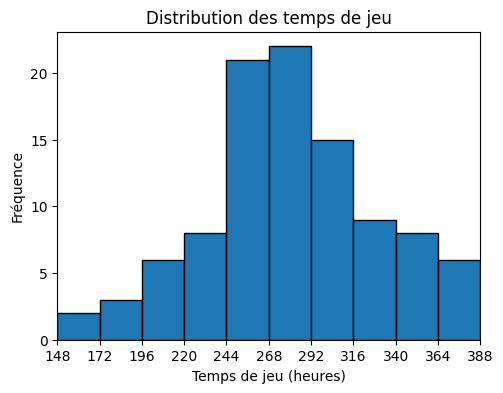

In [12]:
nb_bins = np.sqrt(len(temps_de_jeu)).astype(int)
bin_width = etendue // nb_bins + 1
histogram_max = bin_width * nb_bins + minimum + 1

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(temps_de_jeu, bins=np.arange(minimum, histogram_max, bin_width), edgecolor="black")
plt.xticks(range(minimum, histogram_max, bin_width))
plt.title("Distribution des temps de jeu")
plt.xlabel("Temps de jeu (heures)")
plt.xlim(minimum, histogram_max - 1)
plt.ylabel("Fréquence")

print("Tableau des classes")
print("="*113)
print("| Classe\t| Limites\t| centres\t| Fréquences\t| Fréquences relatives\t| Fréquences cumulées\t|")
print("="*113)

classes = []
for i in range(nb_bins):
    classe_min = minimum + i * bin_width
    classe_max = classe_min + bin_width - 1
    centre = (classe_min + classe_max) / 2
    frequence = np.sum((temps_de_jeu >= classe_min) & (temps_de_jeu <= classe_max))
    frequence_relative = frequence / len(temps_de_jeu)
    frequence_cumulee = np.sum((temps_de_jeu <= classe_max)) / len(temps_de_jeu)
    classes.append(frequence)
    if classe_max == minimum + nb_bins * bin_width - 1:
        classe_max = np.inf
    if classe_min == minimum:
        classe_min = -np.inf
    print(f"| {i+1}\t\t| [{classe_min}, {classe_max+1}[\t| {centre}\t\t| {frequence}\t\t| {frequence_relative:.2f}\t\t\t| {frequence_cumulee:.2f}\t\t\t|")
    print("-"*113)
    

## iii) Vérification de la normalité (test d’ajustement)

Objectif : vérifier quantitativement si les données peuvent être modélisées par une loi normale.

Le code :
- calcule les probabilités théoriques par classe avec la loi normale ($\mu=\bar{x}$, $\sigma=s$),
- convertit ces probabilités en effectifs attendus,
- regroupe les classes pour respecter la condition d’effectif attendu minimal,
- calcule la statistique du $\chi^2$ et la compare à la valeur critique.

Le nombre de groupes est ramené à 7 pour garantir un effectif attendu d’au moins 5 par classe.

In [13]:
alpha = 0.05 # significance

# Bornes pour map les probabilité entre eux
bornes = minimum + np.arange(nb_bins + 1) * bin_width

# Probabilité de chaque intervalle
probabilites = (
    stats.norm.cdf(bornes[1:], loc=moyenne, scale=ecart_type)
    - stats.norm.cdf(bornes[:-1], loc=moyenne, scale=ecart_type)
)

# Conversion en effectifs attendus par classe
classes_normales = (probabilites * 100).tolist()

# on ajuste les classes pour avoir un minimum de 5
classes_ajuste_normale = [float(np.sum(classes_normales[0:3]))] + classes_normales[3:-2] + [float(np.sum(classes_normales[-2:]))]
classes_ajuste = [float(np.sum(classes[0:3]))] + classes[3:-2] + [float(np.sum(classes[-2:]))]

ki2 = 0
for i in range(len(classes_ajuste)):
    ki2 += (classes_ajuste[i] - classes_ajuste_normale[i]) ** 2 / classes_ajuste_normale[i]
df = len(classes_ajuste) - 1

print(f"Degré de liberté (df) = {df}")
valeur_critique = 12.59 # valeur tabulée du khi2 pour df = 6 (n - 1 pour ajusté) et alpha = 0.05
print(f"Valeur critique pour alpha={alpha} : {valeur_critique:.2f}")
print(f"Statistique du khi2: {ki2:.2f}")

print("Tableau des classes ajustées")
print("=" * 73)
print("| i\t| Intervalle\t| Oi (observé)\t| Ei (normal)\t| (Oi-Ei)^2/Ei\t|")
print("=" * 73)

intervalles = [f"[-inf, {bornes[3]}["]
intervalles += [f"[{bornes[k]}, {bornes[k+1]}[" for k in range(3, len(bornes) - 3)]
intervalles += [f"[{bornes[-3]}, +inf["]

for i, (obs, exp) in enumerate(zip(classes_ajuste, classes_ajuste_normale), start=1):
    contribution = (obs - exp) ** 2 / exp
    print(f"| {i}\t| {intervalles[i-1]}\t| {obs:.2f}\t\t| {exp:.2f}\t\t| {contribution:.4f}\t|")
    print("-" * 73)


Degré de liberté (df) = 6
Valeur critique pour alpha=0.05 : 12.59
Statistique du khi2: 5.34
Tableau des classes ajustées
| i	| Intervalle	| Oi (observé)	| Ei (normal)	| (Oi-Ei)^2/Ei	|
| 1	| [-inf, 220[	| 11.00		| 10.93		| 0.0004	|
-------------------------------------------------------------------------
| 2	| [220, 244[	| 8.00		| 11.94		| 1.2975	|
-------------------------------------------------------------------------
| 3	| [244, 268[	| 21.00		| 16.82		| 1.0413	|
-------------------------------------------------------------------------
| 4	| [268, 292[	| 22.00		| 18.92		| 0.5016	|
-------------------------------------------------------------------------
| 5	| [292, 316[	| 15.00		| 17.00		| 0.2351	|
-------------------------------------------------------------------------
| 6	| [316, 340[	| 9.00		| 12.20		| 0.8382	|
-------------------------------------------------------------------------
| 7	| [340, +inf[	| 14.00		| 10.19		| 1.4276	|
--------------------------------------------------

## iv) Intervalle de confiance à 95 % pour la moyenne

Objectif : construire l’intervalle de confiance de la moyenne au niveau de confiance de 95 %.

Le code applique la formule :
$$B = \bar{x} \pm z_{97.5\%}\, s$$
avec $z_{97.5\%}=1.96$ (tables de la loi normale centrée réduite).

In [14]:
niveau_confiance = 0.95 # 1-alpha ou encore P(x1 < X < x2) (en pourcentage)
# Cote Z de notre niveau de confiance
# soit le Z entre 0 < Z < z (indice alpha/2)
# donc indice de 0.05 /2 => 0.025
z = 1.96 # valeur tabulée de la loi normale centrée réduite pour 95%

marge_erreur = z * ecart_type
borne_inferieure = moyenne - marge_erreur
borne_superieure = moyenne + marge_erreur

print(f"Interval de confiance pour la moyenne à 95% : [{borne_inferieure:.2f}, {borne_superieure:.2f}]")

Interval de confiance pour la moyenne à 95% : [182.34, 378.82]


## v) Test d’hypothèse sur la moyenne et erreur de première espèce

Objectif : tester l’hypothèse nulle selon laquelle la moyenne est d’au moins 300 minutes par semaine, au seuil de 5 %.

Le code calcule la valeur critique puis conclut au rejet ou au non-rejet de $H_0$.

L’erreur de première espèce vaut $\alpha=5\%$.

In [15]:
n = len(temps_de_jeu)
moyenne_estime = 300 # 5h
z = -1.645 # Z pour le 5% dans la table (voir IV)

ecart_type_approprie = ecart_type / np.sqrt(n) # S / sqrt(n)
valeur_critique = z * ecart_type_approprie + moyenne_estime

print("Moyenne\t\t: ", moyenne)
print("Valeur Critique\t: ", valeur_critique)
print("Conclusion\t: ", "Rejet de H0" if moyenne < valeur_critique else "H0 est valide")

print(f"L'erreur de première espèce (alpha) est de 5% puisque le seuil est à 95%")

Moyenne		:  280.58
Valeur Critique	:  291.75452286814766
Conclusion	:  Rejet de H0
L'erreur de première espèce (alpha) est de 5% puisque le seuil est à 95%


## vi) Erreur de deuxième espèce

Objectif : estimer l’erreur de deuxième espèce ($\beta$) quand on ne rejette pas $H_0$, en supposant que la moyenne observée représente la moyenne observé.

Le code réutilise la valeur critique précédente, calcule un nouveau score $Z$, puis déduit la probabilité d'un faux positif pour le premier degrée.

In [16]:
z = (valeur_critique - moyenne) / ecart_type_approprie 

print("Nouveau Z ajusté à la moyenne échantillonnale : ", z)

probabilite = 0.9867 # Trouvé dans la table de la loi normale centrée réduite pour Z = 2.22
pourcentage = 1 - probabilite

print(f"Probabilité d'accepter une fausse valeur sur l'hypothèse nulle : {pourcentage:.2f} ({pourcentage*100:.2f}%)")

Nouveau Z ajusté à la moyenne échantillonnale :  2.2293543265183233
Probabilité d'accepter une fausse valeur sur l'hypothèse nulle : 0.01 (1.33%)


## vii) Test d’hypothèse bilatéral sur la variance

Objectif : vérifier si la variance observée est compatible avec l’hypothèse d’un écart-type de 50 minutes, avec $\alpha=5\%$.

Le code calcule la statistique $\chi^2$ de la variance et la compare aux bornes tabulées (ddl = 99, approximé à 100).

In [17]:
n = len(temps_de_jeu)
ecart_type_estime = 50
print(f"Écart-type estimé : {ecart_type_estime}")
print(f"Écart-type observé : {ecart_type:.2f}")
x2 = (n - 1) * (ecart_type ** 2) / (ecart_type_estime ** 2)

borne_inferieure = 77.93 # Trouvé dans la table du khi2 pour df = 99 ~ 100 et alpha = 97.5%
borne_superieure = 129.56 # Trouvé dans la table du khi2 pour df = 99 ~ 100 et alpha = 2.5%

print(f"Borne supérieure : {borne_superieure:.2f}")
print(f"Statistique de test de la variance bilatérale : {x2:.2f}")
print(f"Borne inférieure : {borne_inferieure:.2f}")

print(f"Confirme l'Hypothèse, car elle est entre les deux bornes: {borne_inferieure:.2f} < {x2:.2f} < {borne_superieure:.2f}")

Écart-type estimé : 50
Écart-type observé : 50.12
Borne supérieure : 129.56
Statistique de test de la variance bilatérale : 99.49
Borne inférieure : 77.93
Confirme l'Hypothèse, car elle est entre les deux bornes: 77.93 < 99.49 < 129.56


# Mandat no. 3 : Simulation Monte-Carlo

In [18]:
# Simulations Monte-Carlo
import numpy as np
import matplotlib.pyplot as plt
import math


In [19]:
class exponentiel_distribution:

    def __init__(self, λ):
        self.λ = λ

    def f(self, x):
        return self.λ * np.exp(-self.λ * x)

    def E(self):
        return 1 / self.λ
    
    def V(self):
        return 1 / self.λ**2

In [20]:
class poisson_distribution:

    def __init__(self, λ):
        self.λ = λ

    def f(self, x, T):
        return (np.exp(-self.λ*T)*(self.λ*T)**x) / math.factorial(x)
    
    def E(self, T):
        return self.λ*T
    
    def V(self, T):
        return self.λ*T

In [21]:
class normal_distribution:

    def __init__(self, o, u):
        self.o = o
        self.u = u

    def f(self, x):
        a = -(x-self.u)**2 / (2*self.o**2)
        return (1 / (self.o*np.sqrt(2*np.pi))) * np.exp(a)

## Simulations de connection avec différent taux moyen d'arrivées λ
Les données $\sigma$ = 50.12 et $\mu$ = 280.58 ont été récupéré au mandat no. 2 


Les simulations auront 10 000 connections où l'on calculera les joueurs présents sur 300 minutes de temps total.

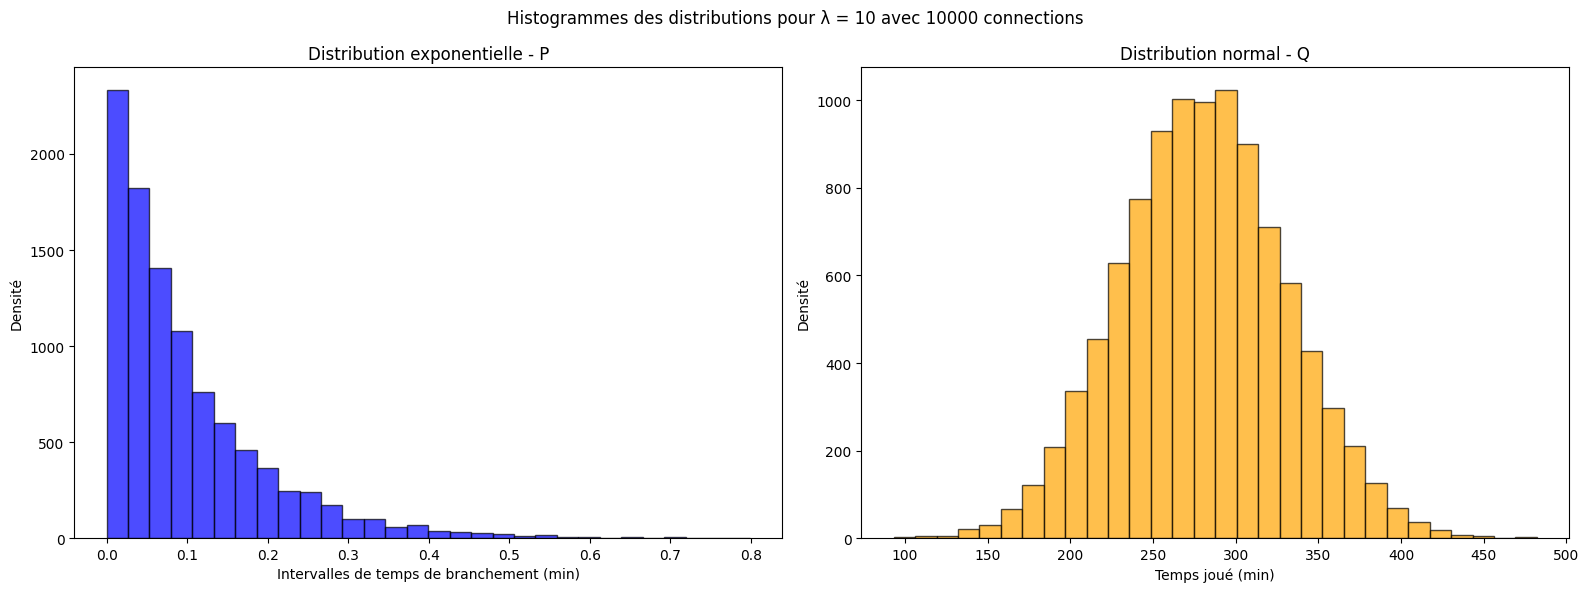

Nombre de joueurs présents pour 300 minutes : 3446


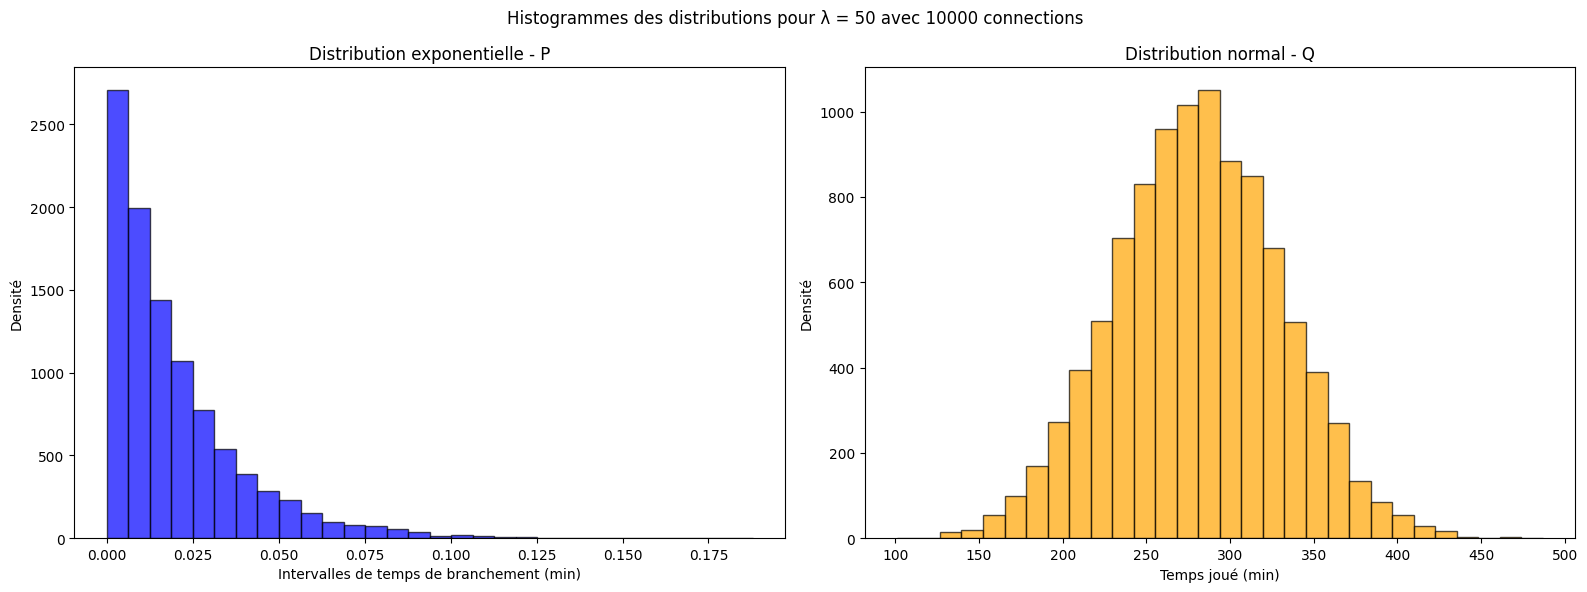

Nombre de joueurs présents pour 300 minutes : 3506


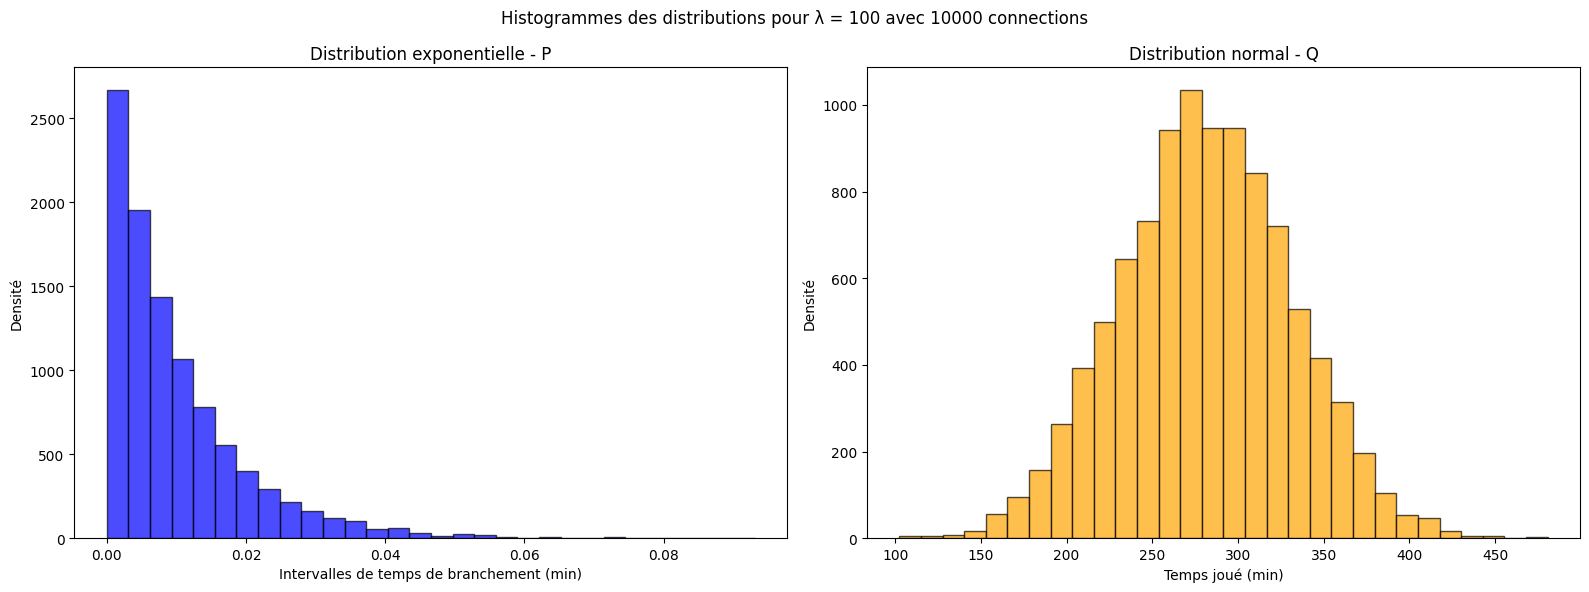

Nombre de joueurs présents pour 300 minutes : 3571


In [22]:
def sim(λ, t):
    N = 10_000
    
    P = np.random.exponential(1/λ, N) # intervalles
    P = P[P <= t] # instants de branchement

    u = 280.58
    o = 50.12
    Q = np.random.normal(u, o, N) # temps joué

    R = P + Q # temps joué fini
    J = np.sum((P <= t) & (R >=t)) # joueurs présents

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    plt.hist(P, bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f'Distribution exponentielle - P')
    plt.xlabel("Intervalles de temps de branchement (min)")
    plt.ylabel("Densité")
    plt.subplot(1, 2, 2)
    plt.hist(Q, bins=30, alpha=0.7, color='orange', edgecolor='black')
    plt.title(f'Distribution normal - Q')
    plt.xlabel("Temps joué (min)")
    plt.ylabel("Densité")
    plt.suptitle(f'Histogrammes des distributions pour λ = {λ} avec {N} connections')
    plt.tight_layout()
    plt.show()

    print(f'Nombre de joueurs présents pour {t} minutes : {J}')

λs = [10, 50, 100] # branchements
t = 300 # En minute

sim(λs[0], t)
sim(λs[1], t)
sim(λs[2], t)

